In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [6]:
# Load Dataset
df = pd.read_csv("train (1).csv")   


In [7]:
# Select Features and Target
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = df['SalePrice']

In [9]:
# Remove missing values if any
data = pd.concat([X, y], axis=1).dropna()
X = data[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = data['SalePrice']


In [10]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# Train Model
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
# Predictions
y_pred = model.predict(X_test)


In [16]:
# Evaluation
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"🏠 Overall R² Score: {r2:.4f} (1.0 is perfect)")
print(f"📉 Mean Squared Error: {mse:.2f}")
print(f"📈 RMSE: {rmse:.2f}")

🏠 Overall R² Score: 0.6341 (1.0 is perfect)
📉 Mean Squared Error: 2806426667.25
📈 RMSE: 52975.72


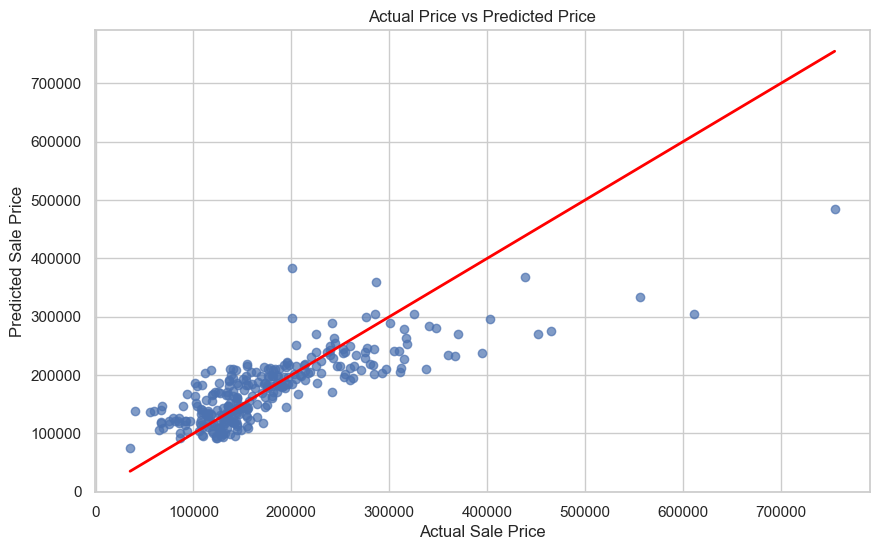

In [17]:
# Graph: Actual vs Predicted
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.title("Actual Price vs Predicted Price")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.grid(True)
plt.show()


In [18]:
# Custom Prediction Function
def predict_house_price(area, bedrooms, bathrooms):
    prediction = model.predict([[area, bedrooms, bathrooms]])[0]
    
    print(f"\n🏡 Prediction for House:")
    print(f"Living Area: {area} sq ft")
    print(f"Bedrooms: {bedrooms}")
    print(f"Bathrooms: {bathrooms}")
    print(f"Estimated Price: ${prediction:,.0f}")


In [19]:

try:
    area = float(input("Enter Living Area (sq ft): "))
    bedrooms = int(input("Enter Number of Bedrooms: "))
    bathrooms = int(input("Enter Number of Bathrooms: "))

    predict_house_price(area, bedrooms, bathrooms)

except ValueError:
    print("❌ Invalid input! Please enter numbers only.")


🏡 Prediction for House:
Living Area: 150.0 sq ft
Bedrooms: 2
Bathrooms: 3
Estimated Price: $104,598


c:\Users\GALAXY BOOK4\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
